# Linear MPC of two masses and a spring: the LQR limit, a terminal set, sparse against condensed

Two masses on a line, joined by a spring, with a force on the first: a linear system whose model
predictive controller (MPC) is a quadratic program (QP). This notebook builds that controller with
`scaly.mpc` and PIQP and checks the three facts linear MPC rests on. Without constraints it is the
LQR, for every horizon. With the LQR cost and the maximal invariant set as terminal ingredients it
stays feasible in closed loop and its optimal cost falls at every step. Its two QP forms, sparse and
condensed, have one solution; the notebook compares their sizes and PIQP's solve times, then writes
the controller as one C function.

| Scaly feature | Where |
| --- | --- |
| `si.zoh` | the exact discretization |
| `mpc.linear`, `mpc.Quadratic`, `mpc.OCP`, `mpc.MPC(..., "piqp")` | every controller |
| `mpc.lqr` | the unconstrained limit, and the terminal cost |
| `mpc.Polytope.box`, `.intersect`, `.preimage`, `.vertices`, `mpc.max_invariant_set` | the terminal set |
| `mpc.OCP(condensed=True)`, `solver_descriptor`, `sc.solver_stats` | sparse against condensed |
| `ctrl.solve`, `mpc.simulate` | the closed loop |
| `ctrl.law`, `write_module` | the generated C |

This notebook needs the vendored PIQP (`uv sync` builds it).

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

import scaly as sc
sys.path.insert(0, str(Path.cwd().parent / "notebooks"))  # the shared plot style
import plotstyle
from scaly import integrators as si
from scaly import mpc
from scaly.codegen import write_module
from scaly.solvers.graph import solver_descriptor

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "mpc" / "linear_mpc"

## The model and its exact discretization

Two unit masses at positions $p_1, p_2$ are joined by a unit spring, and the force $u$ pushes the
first:

$$
\ddot p_1 = p_2 - p_1 + u, \qquad \ddot p_2 = p_1 - p_2, \qquad x = (p_1, p_2, v_1, v_2), \qquad \dot x = A x + B u .
$$

With $u$ held over each interval of $\Delta t = 0.1$ s (a zero-order hold), the map from one sample
to the next is exact:

$$
x_{k+1} = A_d x_k + B_d u_k, \qquad A_d = e^{A \Delta t}, \qquad B_d = \int_0^{\Delta t} e^{A s}\, ds\; B .
$$

`si.zoh` reads both off one matrix exponential of $\begin{bmatrix} A & B \\ 0 & 0 \end{bmatrix} \Delta t$.
The check integrates the continuous system with `solve_ivp` at a tolerance of $10^{-12}$.

In [2]:
DT = 0.1
A = np.array([[0.0, 0.0, 1.0, 0.0], [0.0, 0.0, 0.0, 1.0], [-1.0, 1.0, 0.0, 0.0], [1.0, -1.0, 0.0, 0.0]])
B = np.array([[0.0], [0.0], [1.0], [0.0]])
Ad, Bd = si.zoh(A, B, DT)

rng = np.random.default_rng(0)
zoh_error = 0.0
for _ in range(4):
  x, u = rng.normal(size=4), rng.normal(size=1)
  reference = solve_ivp(lambda _, y, u=u: A @ y + B @ u, (0.0, DT), x, rtol=1e-12, atol=1e-14).y[:, -1]
  zoh_error = max(zoh_error, float(np.abs(Ad @ x + Bd @ u - reference).max()))
print(f"Ad x + Bd u against solve_ivp with u held: {zoh_error:.1e}")

Ad x + Bd u against solve_ivp with u held: 3.0e-14


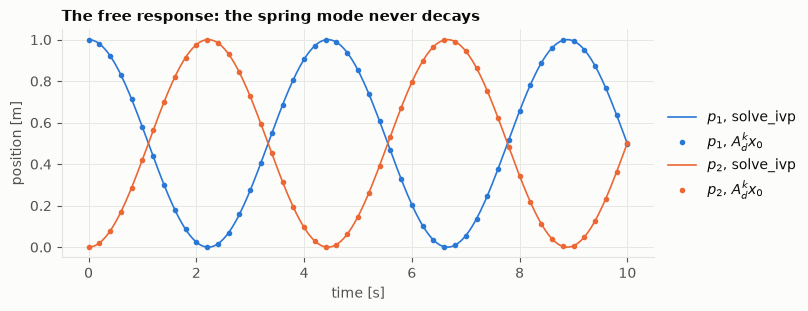

In [3]:
free = [np.array([1.0, 0.0, 0.0, 0.0])]  # the first mass pulled out, then let go
for _ in range(100):
  free.append(Ad @ free[-1])
free = np.array(free)
t_fine = np.linspace(0.0, 100 * DT, 400)
fine = solve_ivp(lambda _, y: A @ y, (0.0, 100 * DT), free[0], t_eval=t_fine, rtol=1e-10, atol=1e-12).y
fig, ax = plt.subplots(figsize=(8, 3))
for i, color in ((0, plotstyle.BLUE), (1, plotstyle.ORANGE)):
  ax.plot(t_fine, fine[i], color=color, lw=1.2, label=f"$p_{i + 1}$, solve_ivp")
  ax.plot(DT * np.arange(101)[::2], free[::2, i], "o", color=color, ms=3, label=f"$p_{i + 1}$, $A_d^k x_0$")
ax.set_xlabel("time [s]")
ax.set_ylabel("position [m]")
ax.set_title("The free response: the spring mode never decays")
fig.legend(loc="outside right center")
plt.show()

The sampled map matches the continuous solution to $3 \times 10^{-14}$. Let go, the masses swap
their energy forever around their common centre at $0.5$ m: the spring mode is undamped, and the
centre of mass is a free double integrator. The controller has to damp both.

## Unconstrained, the MPC is the LQR

With the stage cost $\ell(x, u) = x^\top Q x + u^\top R u$, $Q = I$, $R = 0.1$, `mpc.lqr` solves the
discrete algebraic Riccati equation

$$
P = Q + A_d^\top P A_d - A_d^\top P B_d \left(R + B_d^\top P B_d\right)^{-1} B_d^\top P A_d
$$

(SciPy's solver, with the residual checked) and returns the gain
$K = -(R + B_d^\top P B_d)^{-1} B_d^\top P A_d$ of the law $u = K x$, and $P$, whose quadratic
form $x^\top P x$ is that law's cost to go. $P$ is the fixed point of the Riccati recursion, so with
the terminal cost $x^\top P x$ dynamic programming gives the same cost to go at every stage: an
unconstrained MPC of any horizon $N$ returns $u_0 = K x$ with the optimal cost $V(x) = x^\top P x$.
Each horizon is its own QP and its own generated solver.

In [4]:
Q, R = np.eye(4), 0.1 * np.eye(1)
K, P = mpc.lqr(Ad, Bd, Q, R)
PIQP = {"eps_abs": 1e-10, "eps_rel": 1e-10}
step = mpc.linear(Ad, Bd, name="linmpc_springs_step")
print(f"K = {np.array2string(K[0], precision=3)}; closed-loop spectral radius {np.abs(np.linalg.eigvals(Ad + Bd @ K)).max():.4f}")

LQR_STATES = np.array([[1.0, -0.5, 0.3, 0.0], [-3.0, 2.0, 0.0, 1.5], [0.2, 0.2, -2.0, 1.0]])
lqr_rows = []
for horizon in (1, 5, 20):
  ocp = mpc.OCP(step=step, horizon=horizon, stage_cost=mpc.Quadratic(Q, R), terminal_cost=mpc.Quadratic(P), name=f"linmpc_springs_u{horizon}")
  ctrl = mpc.MPC(ocp, "piqp", options=PIQP)
  u_error = cost_error = 0.0
  for x in LQR_STATES:
    solution = ctrl.solve(x, guess=ctrl.initial_guess(x))
    u_error = max(u_error, float(np.abs(solution.us[0] - K @ x).max()))
    cost_error = max(cost_error, float(abs(solution.cost - x @ P @ x) / (x @ P @ x)))
  lqr_rows.append((horizon, u_error, cost_error))
print(f"{'N':>3} {'|u_0 - K x|':>12} {'|V - xPx| / xPx':>16}")
for horizon, u_error, cost_error in lqr_rows:
  print(f"{horizon:>3} {u_error:>12.1e} {cost_error:>16.1e}")

K = [-4.741  1.203 -3.98  -2.927]; closed-loop spectral radius 0.9533


  N  |u_0 - K x|  |V - xPx| / xPx
  1      8.5e-11          1.5e-11
  5      2.9e-09          4.9e-10
 20      1.6e-12          3.9e-13


For $N = 1$, $5$ and $20$ the first control is $K x$ to $3 \times 10^{-9}$ and the optimal cost is
$x^\top P x$ to $5 \times 10^{-10}$, relative, at PIQP's tolerance of $10^{-10}$. The LQR closed
loop's spectral radius is $0.953$: even under the LQR the spring mode stays lightly damped.

## Constraints and the maximal invariant set

Now the force, the positions and the speeds are bounded: $|u| \le 1$, $|p_i| \le 2$,
$|v_i| \le 0.5$, a box $\mathcal X$ for the state and $\mathcal U$ for the control. The MPC is the QP

$$
\begin{aligned}
\min_{x, u}\ & \sum_{k=0}^{N-1} \left( x_k^\top Q x_k + u_k^\top R u_k \right) + x_N^\top P x_N \\
\text{s.t.}\ & x_0 = \hat x, \quad x_{k+1} = A_d x_k + B_d u_k, \quad u_k \in \mathcal U, \quad x_k \in \mathcal X \ (k \ge 1), \quad x_N \in \mathcal O .
\end{aligned}
$$

The terminal set $\mathcal O$ is the maximal positively invariant set of the LQR closed loop
$x^+ = A_K x$, $A_K = A_d + B_d K$, inside $\mathcal C = \mathcal X \cap \{x : K x \in \mathcal U\}$,
where `U.preimage(K)` is the second set. It is the set of states whose whole LQR trajectory stays in
$\mathcal C$:

$$
\mathcal O = \{x : H A_K^t x \le h,\ t = 0, 1, 2, \dots\}, \qquad \mathcal C = \{x : H x \le h\} .
$$

`mpc.max_invariant_set` follows Gilbert and Tan (IEEE Transactions on Automatic Control, 1991): it
adds the rows of $t = 1, 2, \dots$ until every new row is redundant, one linear program per row,
which proves every later row redundant too, then removes the redundant rows. With $\mathcal O$ and
$P$ as terminal ingredients, the shifted solution with $K x_N$ appended stays feasible at the next
sample, and so the optimal cost $V$ falls by at least the stage cost:
$V(x^+) \le V(x) - \ell(x, u)$.

The same construction for one mass alone, a double integrator with $x = (p, v)$, gives a second
system for the comparison of QP forms below.

In [5]:
U_MAX, P_MAX, V_MAX = 1.0, 2.0, 0.5  # force [N], positions [m], speeds [m/s]


def limits(ad, bd, k):
  # The state bound, C (the box and |K x| <= U_MAX) and the maximal invariant set of the LQR in it.
  half = ad.shape[0] // 2
  x_hi = np.concatenate([np.full(half, P_MAX), np.full(half, V_MAX)])
  c_set = mpc.Polytope.box(-x_hi, x_hi).intersect(mpc.Polytope.box(-U_MAX, U_MAX).preimage(k))
  started = time.perf_counter()
  o_set = mpc.max_invariant_set(ad + bd @ k, c_set)
  return x_hi, c_set, o_set, time.perf_counter() - started


x_hi, C, O_inf, seconds = limits(Ad, Bd, K)
print(f"two masses: C has {C.h.size} rows; the maximal invariant set has {O_inf.h.size} facets, in {seconds:.2f} s")

Ad2, Bd2 = si.zoh(np.array([[0.0, 1.0], [0.0, 0.0]]), np.array([[0.0], [1.0]]), DT)
K2, P2 = mpc.lqr(Ad2, Bd2, np.eye(2), R)
step2 = mpc.linear(Ad2, Bd2, name="linmpc_double_step")
x_hi2, C2, O_inf2, seconds2 = limits(Ad2, Bd2, K2)
print(f"one mass:   C has {C2.h.size} rows; the maximal invariant set has {O_inf2.h.size} facets, in {seconds2:.2f} s")

two masses: C has 10 rows; the maximal invariant set has 66 facets, in 0.34 s
one mass:   C has 6 rows; the maximal invariant set has 12 facets, in 0.03 s


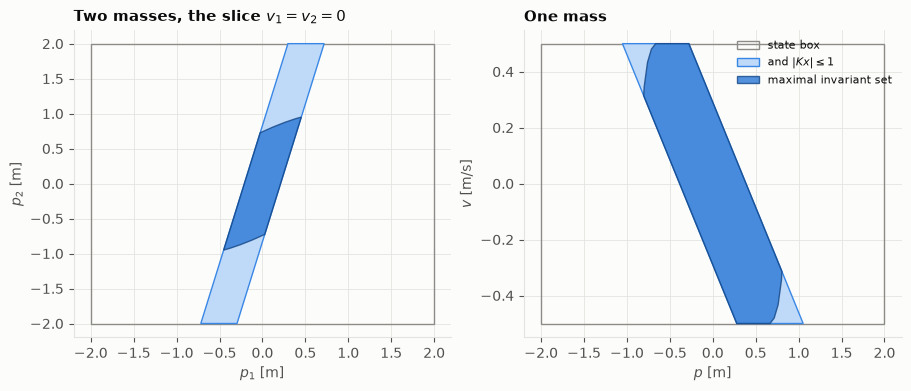

In [6]:
def outline(ax, polytope, **style):
  vertices = polytope.remove_redundancy().vertices()
  ax.fill(*np.vstack([vertices, vertices[:1]]).T, **style)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.8))
at_rest = [mpc.Polytope(s.H[:, :2], s.h) for s in (mpc.Polytope.box(-x_hi, x_hi), C, O_inf)]  # the slice v1 = v2 = 0
for ax, (box, c_set, o_set), labels in (
  (ax1, at_rest, ("$p_1$ [m]", "$p_2$ [m]")),
  (ax2, (mpc.Polytope.box(-x_hi2, x_hi2), C2, O_inf2), ("$p$ [m]", "$v$ [m/s]")),
):
  outline(ax, box, fill=False, ec=plotstyle.NEUTRAL, lw=1, label="state box")
  outline(ax, c_set, fc=plotstyle.BLUES(0.2), ec=plotstyle.BLUES(0.5), lw=1, label="and $|Kx| \\leq 1$")
  outline(ax, o_set, fc=plotstyle.BLUE, alpha=0.8, ec=plotstyle.BLUES(0.9), lw=1, label="maximal invariant set")
  ax.set_xlabel(labels[0])
  ax.set_ylabel(labels[1])
ax1.set_title("Two masses, the slice $v_1 = v_2 = 0$")
ax2.set_title("One mass")
ax2.legend(loc="upper right", fontsize=8)
plt.show()

The set takes 66 facets in four dimensions and 12 for one mass, each computed in a fraction of a
second. In the slice at rest, where $K x = -4.74\, p_1 + 1.20\, p_2$, the input constraint
$|K x| \le 1$ alone cuts the state box down to a thin band: the LQR pushes hard against a displaced
first mass. Invariance trims the band to $|p_2| \le 0.95$, the states from which the LQR never asks
for more force than there is nor lets a speed pass $0.5$ m/s on the way in. For one mass it cuts off
the band's two corners where the speed would pass its bound.

## Sparse against condensed

`mpc.OCP` builds the QP in one of two forms.

- The sparse form, the default: the variables are $(x_0, \dots, x_N, u_0, \dots, u_{N-1})$, the dynamics
  are equality rows, and the state box is a bound on variables. The KKT matrix is banded, and
  `mpc.MPC` runs PIQP's sparse backend on it.
- The condensed form, `condensed=True`: the states are eliminated,
  $x_k = A_d^k \hat x + \sum_{j<k} A_d^{k-1-j} B_d u_j$, a `scan` of the step from $\hat x$. The
  variables are the $N$ controls alone, the Hessian is dense, and every state bound becomes an
  inequality row.

Both are built for $N = 10$ and $50$ and for both systems, and solved from the same state with the
force at its bound, twenty times each, for the median of PIQP's own timings: `t_fe` for evaluating
the QP's data in generated code, `t_qp` for PIQP itself. "Stored" counts the matrix entries PIQP
holds: the nonzeros of $P$, $A$ and $G$ for the sparse backend, every entry for the dense one.

In [7]:
X0 = {4: np.array([1.0, 1.0, 0.0, 0.0]), 2: np.array([1.0, 0.0])}  # pulled out: the force and a speed reach their bounds
SYSTEMS = {4: (step, Q, P, x_hi, O_inf), 2: (step2, np.eye(2), P2, x_hi2, O_inf2)}


def constrained(nx, horizon, condensed=False):
  step_fn, q, p, hi, terminal = SYSTEMS[nx]
  name = f"linmpc_{'springs' if nx == 4 else 'double'}_c{horizon}{'_condensed' if condensed else ''}"
  return mpc.OCP(
    step=step_fn,
    horizon=horizon,
    stage_cost=mpc.Quadratic(q, R),
    terminal_cost=mpc.Quadratic(p),
    u_bounds=(-U_MAX, U_MAX),
    x_bounds=(-hi, hi),
    terminal=terminal,
    condensed=condensed,
    name=name,
  )


def size_of(ctrl):
  desc = solver_descriptor(ctrl.solver)
  lb, ub = ctrl.ocp.layout.bounds()  # one Expr per variable leaf, or a bare one for a single leaf
  lb, ub = (lb, ub) if isinstance(lb, tuple) else ((lb,), (ub,))
  bounded = sum(int(np.sum(np.isfinite(lo.value) | np.isfinite(hi.value))) for lo, hi in zip(lb, ub, strict=True))
  stored = (
    sum(s.nnz for s in (desc.P_sparsity, desc.A_sparsity, desc.G_sparsity) if s is not None)
    if desc.sparse
    else desc.n * (desc.n + desc.n_eq + desc.n_ineq)
  )
  return desc.n, desc.n_eq, desc.n_ineq, bounded, stored


table, form_differences, controllers = [], [], {}
for nx in (4, 2):
  for horizon in (10, 50):
    solutions = {}
    for condensed in (False, True):
      ctrl = mpc.MPC(constrained(nx, horizon, condensed), "piqp", options=PIQP)
      times = []
      for _ in range(20):
        solution = ctrl.solve(X0[nx], guess=ctrl.initial_guess(X0[nx]))
        stats = sc.solver_stats(ctrl.solver)
        times.append((stats.t_fe, stats.t_qp, stats.t_total))
      solutions[condensed], controllers[nx, horizon, condensed] = solution, ctrl
      ms = tuple(float(v) for v in 1e3 * np.median(times, axis=0))
      table.append((nx, horizon, "condensed" if condensed else "sparse", *size_of(ctrl), solution.status.name, solution.status.iter, *ms))
    sparse, dense = solutions[False], solutions[True]
    form_differences.append((nx, horizon, float(np.abs(sparse.us - dense.us).max()), float(np.abs(sparse.xs - dense.xs).max())))

print(
  f"{'nx':>2} {'N':>3} {'form':<10} {'vars':>5} {'eq':>4} {'ineq':>5} {'bounded':>7} {'stored':>7} {'status':<6} {'iter':>4} {'data ms':>8} {'PIQP ms':>8} {'total ms':>8}"
)
for nx, horizon, label, n, n_eq, n_ineq, bounded, stored, status, iterations, fe, qp, total in table:
  print(
    f"{nx:>2} {horizon:>3} {label:<10} {n:>5} {n_eq:>4} {n_ineq:>5} {bounded:>7} {stored:>7} {status:<6} {iterations:>4} {fe:>8.3f} {qp:>8.3f} {total:>8.3f}"
  )
for nx, horizon, du, dx in form_differences:
  print(f"nx = {nx}, N = {horizon:>2}: the two forms' controls differ by {du:.1e}, their states by {dx:.1e}")

nx   N form        vars   eq  ineq bounded  stored status iter  data ms  PIQP ms total ms
 4  10 sparse        54   44    66      50     556 OK        9    0.000    0.145    0.145
 4  10 condensed     10    0   106      10    1160 OK       14    0.004    0.119    0.123
 4  50 sparse       254  204    66     250    1716 OK        9    0.011    0.513    0.525
 4  50 condensed     50    0   266      50   15800 OK       14    0.060    1.195    1.259
 2  10 sparse        32   22    12      30     127 OK       10    0.000    0.050    0.050
 2  10 condensed     10    0    32      10     420 OK       13    0.000    0.048    0.048
 2  50 sparse       152  102    12     150     527 OK        9    0.004    0.185    0.189
 2  50 condensed     50    0   112      50    8100 OK       13    0.027    0.567    0.596
nx = 4, N = 10: the two forms' controls differ by 1.6e-09, their states by 1.5e-10
nx = 4, N = 50: the two forms' controls differ by 1.5e-08, their states by 2.0e-09
nx = 2, N = 10: the two 

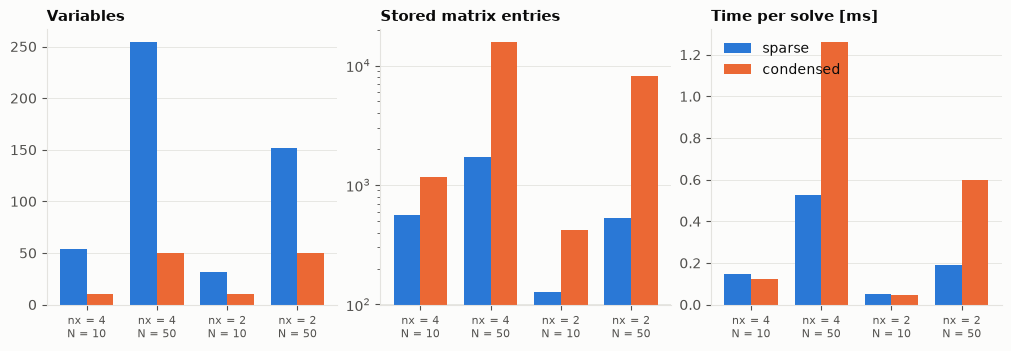

In [8]:
labels = [f"nx = {nx}\nN = {horizon}" for nx, horizon in ((4, 10), (4, 50), (2, 10), (2, 50))]
sparse_rows, dense_rows = table[0::2], table[1::2]
position, width = np.arange(len(labels)), 0.38
fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
for ax, column, title in ((axes[0], 3, "Variables"), (axes[1], 7, "Stored matrix entries"), (axes[2], 12, "Time per solve [ms]")):
  ax.bar(position - width / 2, [r[column] for r in sparse_rows], width, color=plotstyle.BLUE, label="sparse")
  ax.bar(position + width / 2, [r[column] for r in dense_rows], width, color=plotstyle.ORANGE, label="condensed")
  ax.set_xticks(position, labels, fontsize=8)
  ax.set_title(title)
  ax.grid(axis="x", visible=False)
axes[1].set_yscale("log")
axes[2].legend(loc="upper left")
plt.show()

Every solve succeeds, and the two forms agree: their controls differ by at most $2.5 \times 10^{-8}$
and their states by $2.5 \times 10^{-9}$, which is PIQP's tolerance carried through a 50-step
horizon. The sizes follow the forms. The sparse QP for the two masses at $N = 50$ has 254 variables,
204 equality rows and only the terminal set's 66 inequality rows, its 250 bounded variables handled
as bounds; the condensed one has 50 variables and no equalities, but $50 \cdot 4$ state rows join
the terminal set's for 266 inequality rows, and its dense matrices hold 15 800 entries against the
sparse form's 1 716. At $N = 10$ the two cost about the same; at $N = 50$ the condensed QP takes
more than twice as long, while PIQP's iteration counts stay at 9 or 10 (sparse) and 13 or 14 (condensed)
for every horizon. Evaluating the QP's data is a small part of either: the generated code takes
microseconds, and the time is PIQP's.

## Closed loop: recursive feasibility and a falling cost

The sparse $N = 10$ controller runs for 80 steps on the exact plant, from both masses pulled out to
$1$ m, through `mpc.simulate`, which calls the controller's law and records PIQP's status,
iterations and time at each step. Then the optimal cost $V$ is recomputed at every visited state by
a fresh solve, which gives the margin

$$
V(x_k) - \ell(x_k, u_k) - V(x_{k+1}) \ \ge\ 0
$$

that the terminal ingredients guarantee.

In [9]:
STEPS = 80
ctrl = controllers[4, 10, False]
run = mpc.simulate(ctrl, lambda x, u: Ad @ x + Bd @ u, X0[4], STEPS)
solutions = [ctrl.solve(x, guess=ctrl.initial_guess(x)) for x in run.xs]
values = np.array([s.cost for s in solutions])
stage = np.einsum("ki,ij,kj->k", run.xs[:-1], Q, run.xs[:-1]) + np.einsum("ki,ij,kj->k", run.us, R, run.us)
margin = values[:-1] - stage - values[1:]

statuses_ok = sum(name in ("OK", "ACCEPTABLE") for name in run.statuses)
resolve_ok = sum(s.status.ok for s in solutions)
saturated_steps = int(np.sum(np.abs(run.us) >= U_MAX - 1e-6))
speed_bound_steps = int(np.sum(np.abs(run.xs[:, 2:]).max(axis=1) >= V_MAX - 1e-6))
state_bound_excess = float(np.max(np.abs(run.xs) - x_hi))
law_vs_solve = float(np.abs(run.us[:, 0] - np.array([s.us[0, 0] for s in solutions[:-1]])).max())
final_state = float(np.abs(run.xs[-1]).max())
print(f"{statuses_ok}/{STEPS} solves OK in the loop, {resolve_ok}/{STEPS + 1} fresh solves OK at the visited states")
print(
  f"force at its bound for {saturated_steps} steps, a speed at its bound for {speed_bound_steps}; largest state bound excess {state_bound_excess:.1e}"
)
print(
  f"margin V(x) - l(x, u) - V(x+) between {margin.min():.1e} and {margin.max():.1e}; V from {values[0]:.3f} to {values[-1]:.1e}; final |x| {final_state:.1e}"
)
print(f"the law's u against a fresh solve at the same state: {law_vs_solve:.1e}")
print(f"PIQP in the loop: median {np.median(run.iterations):.0f} iterations, {1e3 * np.median(run.solve_times):.3f} ms")

80/80 solves OK in the loop, 81/81 fresh solves OK at the visited states
force at its bound for 5 steps, a speed at its bound for 3; largest state bound excess -7.8e-14
margin V(x) - l(x, u) - V(x+) between -1.3e-10 and 3.9e-10; V from 41.584 to 1.9e-02; final |x| 2.4e-02
the law's u against a fresh solve at the same state: 0.0e+00
PIQP in the loop: median 7 iterations, 0.119 ms


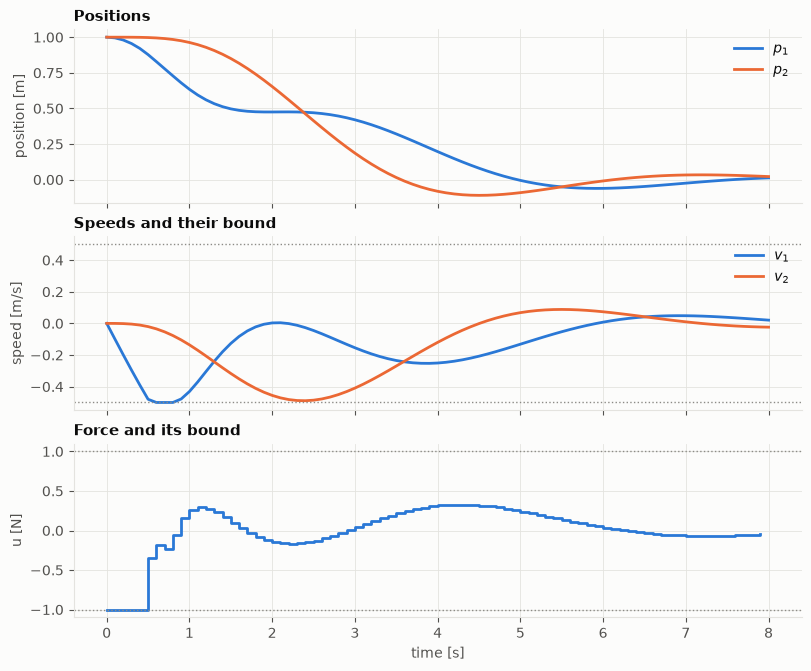

In [10]:
t = DT * np.arange(STEPS + 1)
fig, axes = plt.subplots(3, 1, figsize=(8, 6.6), sharex=True)
axes[0].plot(t, run.xs[:, 0], color=plotstyle.BLUE, label="$p_1$")
axes[0].plot(t, run.xs[:, 1], color=plotstyle.ORANGE, label="$p_2$")
axes[0].set_ylabel("position [m]")
axes[0].set_title("Positions")
axes[0].legend(loc="upper right")
axes[1].plot(t, run.xs[:, 2], color=plotstyle.BLUE, label="$v_1$")
axes[1].plot(t, run.xs[:, 3], color=plotstyle.ORANGE, label="$v_2$")
axes[2].step(t[:-1], run.us[:, 0], where="post", color=plotstyle.BLUE)
for ax, bound in ((axes[1], V_MAX), (axes[2], U_MAX)):
  for side in (-bound, bound):
    ax.axhline(side, color=plotstyle.NEUTRAL, lw=1, ls=":")
axes[1].set_ylabel("speed [m/s]")
axes[1].set_title("Speeds and their bound")
axes[1].legend(loc="upper right")
axes[2].set_ylabel("u [N]")
axes[2].set_title("Force and its bound")
axes[2].set_xlabel("time [s]")
plt.show()

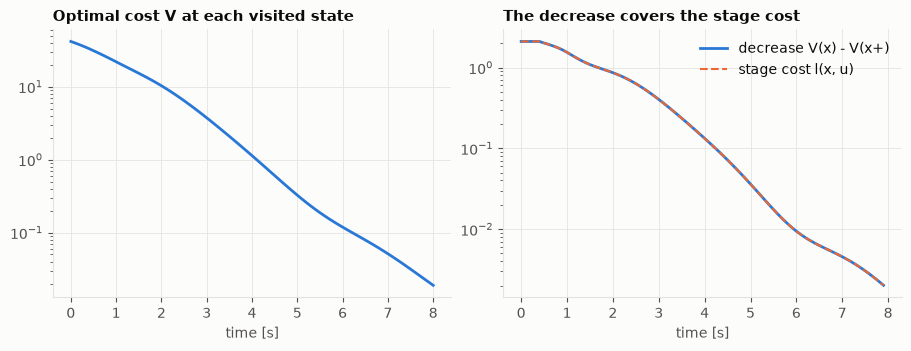

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.4))
ax1.semilogy(t, values, color=plotstyle.BLUE)
ax1.set_xlabel("time [s]")
ax1.set_title("Optimal cost V at each visited state")
ax2.semilogy(t[:-1], values[:-1] - values[1:], color=plotstyle.BLUE, label="decrease V(x) - V(x+)")
ax2.semilogy(t[:-1], stage, "--", color=plotstyle.ORANGE, lw=1.5, label="stage cost l(x, u)")
ax2.set_xlabel("time [s]")
ax2.set_title("The decrease covers the stage cost")
ax2.legend(loc="upper right")
plt.show()

Every one of the 80 solves in the loop succeeds, as do the 81 fresh solves at the visited states.
The force sits at its $-1$ N bound for the first 5 steps; then the first mass's speed runs at its
$-0.5$ m/s bound for 3 steps, touching it to $10^{-13}$ and never passing it, and the second mass's
speed comes within $0.011$ m/s of its bound at 2.4 s. After 8 s the state is within $0.024$ of the
origin, the remaining motion the lightly damped spring mode.

The optimal cost falls from 41.6 to 0.019, and at every step by the stage cost: the margin stays
between $-1.3 \times 10^{-10}$ and $3.9 \times 10^{-10}$, zero to PIQP's tolerance, and the two
curves on the right lie on top of each other. The guarantee is an inequality; it holds with equality
here because the plant is the model and the horizon is long enough: each optimal plan ends in the
region where the LQR is optimal, so it solves the infinite-horizon constrained problem, whose tail is
optimal from the next state on. A model error or a disturbance would open a gap.

The law's control equals a solve from scratch at the same state exactly: PIQP does not read the warm
start yet, so the shifted guess the law carries does not change its result.

## Checks

In [12]:
assert zoh_error < 1e-12
for _, du, dv in lqr_rows:
  assert du < 3e-8 and dv < 5e-9  # u = Kx and V = x'Px for every horizon
for _, _, du, dx in form_differences:
  assert du < 3e-7 and dx < 3e-8  # the condensed QP has the sparse one's solution
rows = {(r[0], r[1], r[2]): r for r in table}
assert all(r[8] == "OK" for r in rows.values())
assert rows[(4, 50, "sparse")][3:6] == (254, 204, 66) and rows[(4, 50, "condensed")][3:6] == (50, 0, 266)
assert {4: O_inf.h.size, 2: O_inf2.h.size} == {4: 66, 2: 12}
assert statuses_ok == 80 and resolve_ok == 81
assert saturated_steps >= 1 and speed_bound_steps >= 1 and state_bound_excess < 1e-8
assert margin.min() > -1e-7  # the cost falls by at least the stage cost at every step
assert law_vs_solve < 1e-8 and final_state < 0.05
law_inputs = tuple((name, int(e.size)) for name, e in zip(ctrl.law.input_names, ctrl.law.inputs, strict=True))
assert law_inputs == (("x0", 4), ("guess", 218))
print("all 12 checks passed")

all 12 checks passed


## The generated C

`ctrl.law` is the whole controller as one Function, `law(x0, guess) -> (u, guess_next)`: PIQP nested,
the QP's data evaluated in generated code, and the warm start shifted by one stage in the same code,
so that a C caller keeps one buffer of `guess_size` doubles between calls. The header declares one
typed struct per buffer.

In [13]:
module = write_module(ctrl.law, GENERATED)
print(f"{module.source_name}: {len(module.source.splitlines())} lines, {len(module.source) / 1e3:.0f} kB; guess_size = {ctrl.guess_size}")
print(f"law({', '.join(f'{name}[{size}]' for name, size in law_inputs)}) -> ({', '.join(ctrl.law.output_names)})")
print()
print(
  "\n".join(line for line in module.header.splitlines() if line.startswith(("int ", "static inline int")) or "SCALY_ALIGNAS(16) double data[" in line)
)

linmpc_springs_c10_law.c: 738 lines, 46 kB; guess_size = 218
law(x0[4], guess[218]) -> (u, guess_next)

int linmpc_springs_c10_law(const double** arg, double** res, int* iw, double* w, int mem);
int linmpc_springs_c10_piqp_stats(scaly_solver_stats* out);
typedef struct { SCALY_ALIGNAS(16) double data[4]; } linmpc_springs_c10_law_x0_t;
typedef struct { SCALY_ALIGNAS(16) double data[218]; } linmpc_springs_c10_law_guess_t;
typedef struct { SCALY_ALIGNAS(16) double data[1]; } linmpc_springs_c10_law_u_t;
typedef struct { SCALY_ALIGNAS(16) double data[218]; } linmpc_springs_c10_law_guess_next_t;
typedef struct { SCALY_ALIGNAS(16) double data[linmpc_springs_c10_law_SZ_W > 0 ? linmpc_springs_c10_law_SZ_W : 1]; } linmpc_springs_c10_law_workspace_t;
static inline int linmpc_springs_c10_law_call(const linmpc_springs_c10_law_x0_t* x0, const linmpc_springs_c10_law_guess_t* guess, linmpc_springs_c10_law_u_t* u, linmpc_springs_c10_law_guess_next_t* guess_next, linmpc_springs_c10_law_workspace_t* work

The source links against the vendored PIQP; the files are in `examples/generated/mpc/linear_mpc/`.